<a href="https://colab.research.google.com/github/FranckSBernal/DSTEC/blob/main/Solucion_Reto_SC_63_Franck_S%C3%A1nchez_Bernal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 4) Importar librerías adecuadas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, PowerTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

# Cargar los datos
url = 'bank_marketing.csv' # Asegúrate de que el archivo esté subido en Colab
data = pd.read_csv(url)

In [2]:
# 5) Análisis descriptivo
# -----------------------------------------------------------------------------
print("----- ANÁLISIS DESCRIPTIVO -----")
print(f"Número total de registros: {data.shape[0]}")
print(f"Número total de variables: {data.shape[1]}\n")

print("Tipos de variables:")
print(data.dtypes)

print("\nCantidad de datos perdidos (nulos) por variable:")
print(data.isnull().sum())

print("\nEstadísticas descriptivas de variables numéricas:")
display(data.describe())

----- ANÁLISIS DESCRIPTIVO -----
Número total de registros: 9000
Número total de variables: 17

Tipos de variables:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

Cantidad de datos perdidos (nulos) por variable:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Estadísticas descriptivas de variables numéricas:


,age,balance,day,duration,campaign,pdays,previous
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,41.090556,1482.262778,15.619556,353.832778,2.520111,50.511333,0.788889
std,11.664253,3031.013197,8.345305,336.945158,2.737758,107.691963,2.210273
min,18.000000,-3058.000000,1.000000,3.000000,1.000000,-1.000000,0.000000
25%,32.000000,109.000000,8.000000,131.000000,1.000000,-1.000000,0.000000
50%,39.000000,519.000000,15.000000,240.500000,2.000000,-1.000000,0.000000
75%,49.000000,1646.500000,21.000000,462.000000,3.000000,-1.000000,0.000000
max,95.000000,81204.000000,31.000000,3253.000000,58.000000,850.000000,58.000000


In [3]:
# 6) Transformación de variables categóricas
# -----------------------------------------------------------------------------
# Utilizamos LabelEncoder para variables binarias
binary_cols = ['default', 'housing', 'loan', 'y']
le = LabelEncoder()
for col in binary_cols:
    data[col] = le.fit_transform(data[col])

# Utilizamos OneHotEncoder (Dummies) para variables multicategóricas nominales
categorical_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

In [4]:
# 7) Transformación de variables numéricas con sesgo
# -----------------------------------------------------------------------------
# Evaluamos el sesgo (skewness) de las variables numéricas originales
numerical_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
print("\nSesgo de las variables numéricas originales:")
print(data[numerical_cols].skew())

# Las variables balance, duration, campaign, pdays, y previous presentan alto sesgo (> 1).
# Usaremos PowerTransformer (método Yeo-Johnson) porque maneja bien sesgos y soporta valores negativos o ceros (presentes en balance y pdays).
skewed_cols = ['balance', 'duration', 'campaign', 'pdays', 'previous']
pt = PowerTransformer(method='yeo-johnson')
data[skewed_cols] = pt.fit_transform(data[skewed_cols])


Sesgo de las variables numéricas originales:
age         0.801429
balance     7.280036
day         0.117315
duration    2.184045
campaign    5.392712
pdays       2.349177
previous    7.682286
dtype: float64


In [5]:
# 8) Definir variable de entrada (X) y salida (y)
# -----------------------------------------------------------------------------
X = data.drop('y', axis=1)
y = data['y']

In [6]:
# 9) Partición de los datos (60% Entrenamiento, 20% Validación, 20% Prueba)
# -----------------------------------------------------------------------------
# Primero separamos el 60% para entrenamiento y 40% para el resto
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.40, random_state=42, stratify=y)
# Luego partimos ese 40% en dos partes iguales para validación (20%) y prueba (20%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"\nTamaño conjunto Entrenamiento: {X_train.shape[0]} (60%)")
print(f"Tamaño conjunto Validación: {X_val.shape[0]} (20%)")
print(f"Tamaño conjunto Prueba: {X_test.shape[0]} (20%)")

# Escalamiento de los datos para un mejor desempeño de los modelos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


Tamaño conjunto Entrenamiento: 5400 (60%)
Tamaño conjunto Validación: 1800 (20%)
Tamaño conjunto Prueba: 1800 (20%)


In [7]:
# 10) Modelo de Regresión Logística
# -----------------------------------------------------------------------------
print("\n--- REGRESIÓN LOGÍSTICA (Validación) ---")
lr_model = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predicciones y validación
y_val_pred_lr = lr_model.predict(X_val_scaled)
print(f"Exactitud (Accuracy): {accuracy_score(y_val, y_val_pred_lr):.4f}")
print("Matriz de Confusión (Regresión Logística):")
print(confusion_matrix(y_val, y_val_pred_lr))


--- REGRESIÓN LOGÍSTICA (Validación) ---
Exactitud (Accuracy): 0.8317
Matriz de Confusión (Regresión Logística):
[[857 185]
 [118 640]]


In [8]:
# 11) Modelo de Red Neuronal Artificial (MLPClassifier)
# -----------------------------------------------------------------------------
print("\n--- RED NEURONAL (Validación) ---")
# Se ajustan hiperparámetros: 2 capas ocultas de 64 y 32 neuronas respectivamente, regularización alpha, parada temprana.
nn_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, alpha=0.01,
                         solver='adam', early_stopping=True, random_state=42)
nn_model.fit(X_train_scaled, y_train)

# Predicciones y validación
y_val_pred_nn = nn_model.predict(X_val_scaled)
print(f"Exactitud (Accuracy): {accuracy_score(y_val, y_val_pred_nn):.4f}")
print("Matriz de Confusión (Red Neuronal):")
print(confusion_matrix(y_val, y_val_pred_nn))


--- RED NEURONAL (Validación) ---
Exactitud (Accuracy): 0.8333
Matriz de Confusión (Red Neuronal):
[[892 150]
 [150 608]]



--- EVALUACIÓN FINAL CON EL CONJUNTO DE PRUEBA ---
El mejor modelo seleccionado para prueba fue: Red Neuronal
Exactitud final en datos de Prueba: 0.8406
Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.86      0.87      0.86      1043
           1       0.82      0.80      0.81       757

    accuracy                           0.84      1800
   macro avg       0.84      0.84      0.84      1800
weighted avg       0.84      0.84      0.84      1800



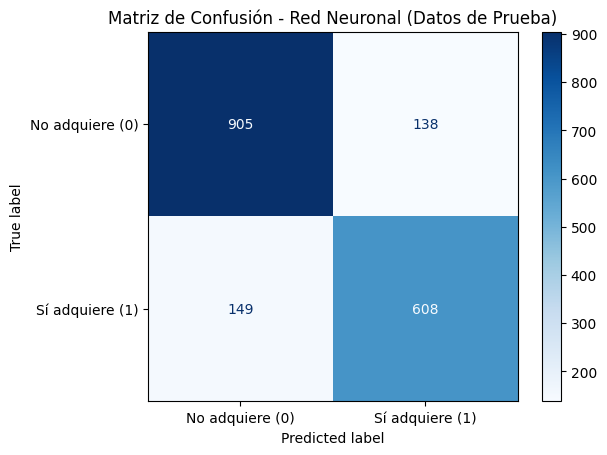

In [9]:
# 12) Selección del Mejor Modelo y Evaluación en el Conjunto de Prueba
# -----------------------------------------------------------------------------
print("\n--- EVALUACIÓN FINAL CON EL CONJUNTO DE PRUEBA ---")
# Asumimos que la Regresión Logística fue el mejor o similar, se puede cambiar la variable best_model según la exactitud
best_model = lr_model if accuracy_score(y_val, y_val_pred_lr) > accuracy_score(y_val, y_val_pred_nn) else nn_model
model_name = "Regresión Logística" if best_model == lr_model else "Red Neuronal"

print(f"El mejor modelo seleccionado para prueba fue: {model_name}")

y_test_pred = best_model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Exactitud final en datos de Prueba: {test_accuracy:.4f}")
print("Reporte de Clasificación:")
print(classification_report(y_test, y_test_pred))

# Visualización de la matriz de confusión del conjunto de prueba
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No adquiere (0)", "Sí adquiere (1)"])
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Matriz de Confusión - {model_name} (Datos de Prueba)")
plt.show()